# Notebook 4 — Carbon-Constrained Portfolio Allocation
## Part II: Portfolio Allocation with Carbon Emission Reduction

This notebook constructs three carbon-constrained portfolios:

- **P_oos_mv(0.5)** (Section 3.2): Long-only MV portfolio with CF ≤ 50% of the unconstrained MV portfolio CF
- **P_oos_vw(0.5)** (Section 3.3): Tracking error minimization with CF ≤ 50% of the VW benchmark CF
- **P_oos_vw(NZ)** (Section 4.1): Net zero portfolio with CF reduced by 10% per year from the 2013 VW baseline

All portfolios use Scope 1 + Scope 2 emissions, European firms, annual rebalancing,
and the same investment set as Notebook 2.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
import os

BASE_DIR  = Path.cwd().parent
CLEAN_DIR = BASE_DIR / "data_clean"
RAW_DIR   = BASE_DIR / "data_raw"
os.makedirs(BASE_DIR / "outputs", exist_ok=True)

## 1. Load Data

In [3]:
# Load all necessary data
returns_raw    = pd.read_excel(CLEAN_DIR / "returns_monthly_clean.xlsx")
scope1_clean   = pd.read_excel(CLEAN_DIR / "scope1_clean.xlsx")
scope2_clean   = pd.read_excel(CLEAN_DIR / "scope2_clean.xlsx")
mv_year_clean  = pd.read_excel(CLEAN_DIR / "market_value_year_clean.xlsx")
mv_month_clean = pd.read_excel(CLEAN_DIR / "market_value_month_clean.xlsx")
static         = pd.read_excel(RAW_DIR / "Static_2025.xlsx")

# Load pre-computed carbon metrics
cf_mv    = pd.read_excel(CLEAN_DIR / "cf_mv.xlsx", index_col=0).squeeze()
cf_vw    = pd.read_excel(CLEAN_DIR / "cf_vw.xlsx", index_col=0).squeeze()
emissions_df       = pd.read_excel(CLEAN_DIR / "emissions.xlsx", index_col=0)
carbon_intensity   = pd.read_excel(CLEAN_DIR / "carbon_intensity.xlsx", index_col=0)
emissions_df.columns      = emissions_df.columns.astype(int)
carbon_intensity.columns  = carbon_intensity.columns.astype(int)

cf_mv.index = cf_mv.index.astype(int)
cf_vw.index = cf_vw.index.astype(int)

print("cf_mv loaded:", cf_mv.shape)
print("cf_vw loaded:", cf_vw.shape)
print("emissions loaded:", emissions_df.shape)

cf_mv loaded: (12,)
cf_vw loaded: (12,)
emissions loaded: (618, 26)


## 2. Rebuild Investment Universe and Base Data

In [4]:
# Filter to Europe
static_europe = static[static["Region"].str.upper() == "EUR"].copy()
isins_europe  = set(static_europe["ISIN"])

# Build returns matrix
returns_matrix = returns_raw[returns_raw["ISIN"].isin(isins_europe)].copy()
returns_matrix = returns_matrix.set_index("ISIN").drop(columns=["NAME"])
returns_matrix.columns = pd.to_datetime(returns_matrix.columns)
returns_matrix = returns_matrix.sort_index(axis=1)

# Build mv_year and mv_month matrices
mv_year = mv_year_clean[mv_year_clean["ISIN"].isin(isins_europe)].copy()
mv_year = mv_year.set_index("ISIN").drop(columns=["NAME"], errors="ignore")
mv_year.columns = mv_year.columns.astype(int)

mv_matrix = mv_month_clean[mv_month_clean["ISIN"].isin(isins_europe)].copy()
mv_matrix = mv_matrix.set_index("ISIN").drop(columns=["NAME"], errors="ignore")
mv_matrix.columns = pd.to_datetime(mv_matrix.columns)
mv_matrix = mv_matrix.sort_index(axis=1)

# Carbon data
isins_scope1 = set(scope1_clean["ISIN"])
isins_scope2 = set(scope2_clean["ISIN"])
has_carbon_global = pd.Series(
    returns_matrix.index.isin(isins_scope1 | isins_scope2),
    index=returns_matrix.index
)

# Pre-compute e_over_cap for all years
e_over_cap_all = {}
for year in range(2013, 2025):
    if year in emissions_df.columns and year in mv_year.columns:
        e_over_cap_all[year] = emissions_df[year].div(mv_year[year].replace(0, np.nan))

# VW weights for tracking error (annual, end of year)
vw_weights_annual = {}
for year in range(2013, 2025):
    if year not in mv_year.columns:
        continue
    caps = mv_year[year].dropna()
    caps = caps[caps > 0]
    vw_weights_annual[year] = caps / caps.sum()

print("Data ready.")
print(f"Returns matrix: {returns_matrix.shape}")

Data ready.
Returns matrix: (633, 314)


## 3. Helper Functions

We define reusable functions for:
- Building the per-year investment set
- Computing the carbon footprint constraint vector
- Running the monthly weight-drift return simulation

In [5]:
def get_investment_set(year, returns_matrix, past_cols, has_carbon_global,
                       e_over_cap_all, emissions_df, mv_year, window=120):
    """Return valid ISINs for a given year after applying all filters."""
    past_ret = returns_matrix[past_cols]

    enough_obs    = past_ret.notna().sum(axis=1) >= 36
    non_nan_count = past_ret.notna().sum(axis=1).replace(0, np.nan)
    zero_count    = (past_ret == 0).sum(axis=1)
    not_stale     = (zero_count / non_nan_count) <= 0.5
    has_price     = past_ret[past_cols[-1]].notna()
    has_carbon    = has_carbon_global

    valid       = enough_obs & not_stale & has_price & has_carbon
    valid_isins = valid[valid].index.tolist()

    if year in e_over_cap_all:
        e_over_cap_y = e_over_cap_all[year]
        cap_year_vw  = mv_year[year].dropna()
        e_year_vw    = emissions_df[year].dropna()
        common_vw    = cap_year_vw.index.intersection(e_year_vw.index)
        if len(common_vw) > 0:
            cf_vw_year = e_year_vw[common_vw].sum() / cap_year_vw[common_vw].sum()
            threshold  = 3 * cf_vw_year
        else:
            threshold  = e_over_cap_y.quantile(0.95)
        e_valid     = e_over_cap_y.reindex(valid_isins).dropna()
        valid_isins = [i for i in valid_isins if
                       i not in e_valid.index or e_over_cap_y.get(i, 0) <= threshold]

    return valid_isins


def get_cf_vector(valid_isins, year, emissions_df, mv_year):
    """Return E_i/Cap_i vector for valid ISINs in a given year."""
    e_year   = emissions_df[year]
    cap_year = mv_year[year]
    e_over_cap = e_year.div(cap_year.replace(0, np.nan))
    e_over_cap = e_over_cap.reindex(valid_isins).fillna(0)
    return e_over_cap.values


def simulate_returns(w, valid_isins, returns_matrix, end_date):
    """Simulate next-year monthly returns with weight drift."""
    next_cols = returns_matrix.columns[
        (returns_matrix.columns > end_date) &
        (returns_matrix.columns <= end_date + pd.DateOffset(years=1))
    ]
    if len(next_cols) == 0:
        return [], []

    next_ret  = returns_matrix.loc[valid_isins, next_cols].fillna(0).values
    w_current = w.copy()
    rets, dates = [], []

    for k in range(next_ret.shape[1]):
        r_t       = next_ret[:, k]
        rp_t      = float(w_current @ r_t)
        rets.append(rp_t)
        dates.append(next_cols[k])
        w_current = w_current * (1 + r_t)
        total     = w_current.sum()
        if total > 0:
            w_current = w_current / total

    return rets, dates


def compute_stats(returns_series, rf_annual=0.02):
    """Compute annualized performance statistics."""
    rf_monthly  = rf_annual / 12
    mean_annual = returns_series.mean() * 12
    vol_annual  = returns_series.std() * np.sqrt(12)
    sharpe      = ((returns_series - rf_monthly).mean() / returns_series.std()) * np.sqrt(12)
    return {
        "Annualized Return":     round(mean_annual, 4),
        "Annualized Volatility": round(vol_annual, 4),
        "Sharpe Ratio":          round(sharpe, 4),
        "Min Monthly Return":    round(returns_series.min(), 4),
        "Max Monthly Return":    round(returns_series.max(), 4)
    }

## 4. Section 3.2 — P_oos_mv(0.5): MV Portfolio with 50% CF Constraint

We solve each year:

min  αᵀ Σ α  
s.t. Σᵢ αᵢ × (Eᵢ/Capᵢ) ≤ 0.5 × CF_mv(Y)  
     Σᵢ αᵢ = 1  
     αᵢ ≥ 0, αᵢ ≤ 0.05

where CF_mv(Y) is the carbon footprint of the unconstrained MV portfolio in year Y.

In [6]:
start_year = 2013
end_year   = 2024
window     = 120

mv05_returns_list = []
mv05_dates_list   = []
mv05_weights      = {}
mv05_cf           = {}

for year in range(start_year, end_year + 1):

    end_date  = pd.Timestamp(f"{year}-12-31")
    past_cols = returns_matrix.columns[returns_matrix.columns <= end_date]
    past_cols = past_cols[-window:]

    if len(past_cols) < window:
        continue
    if year not in cf_mv.index:
        continue

    valid_isins = get_investment_set(
        year, returns_matrix, past_cols, has_carbon_global,
        e_over_cap_all, emissions_df, mv_year
    )

    if len(valid_isins) < 10:
        continue

    sub        = returns_matrix[past_cols].loc[valid_isins]
    sub_filled = sub.T.fillna(sub.T.mean()).T
    mu_sub     = sub_filled.values.mean(axis=1, keepdims=True)
    Sigma      = (sub_filled.values - mu_sub) @ (sub_filled.values - mu_sub).T / sub_filled.shape[1]
    Sigma      = Sigma + 1e-6 * np.eye(len(valid_isins))
    N          = len(valid_isins)

    # Carbon footprint constraint vector
    cf_vec      = get_cf_vector(valid_isins, year, emissions_df, mv_year)
    cf_target   = 0.5 * cf_mv[year]

    def portfolio_variance(w):
        return w @ Sigma @ w

    def portfolio_variance_grad(w):
        return 2 * Sigma @ w

    constraints = [
        {'type': 'eq',  'fun': lambda w: np.sum(w) - 1,
                         'jac': lambda w: np.ones(N)},
        {'type': 'ineq','fun': lambda w: cf_target - cf_vec @ w,
                         'jac': lambda w: -cf_vec}
    ]
    bounds = [(0, 0.05)] * N
    w0     = np.ones(N) / N

    result = minimize(
        portfolio_variance, w0,
        jac=portfolio_variance_grad,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 500}
    )

    if not result.success:
        print(f"Year {year}: P_mv(0.5) optimization failed — {result.message}")
        continue

    w = np.clip(result.x, 0, None)
    w = w / w.sum()

    mv05_weights[year] = pd.Series(w, index=valid_isins)
    mv05_cf[year]      = float(cf_vec @ w)

    rets, dates = simulate_returns(w, valid_isins, returns_matrix, end_date)
    mv05_returns_list.extend(rets)
    mv05_dates_list.extend(dates)

    print(f"Year {year}: CF = {mv05_cf[year]:.2f} (target ≤ {cf_target:.2f})")

mv05_returns = pd.Series(mv05_returns_list, index=mv05_dates_list).sort_index()
print(f"\nP_mv(0.5) returns shape: {mv05_returns.shape}")

Year 2013: CF = 9.68 (target ≤ 9.68)
Year 2014: CF = 7.57 (target ≤ 7.57)
Year 2015: CF = 7.17 (target ≤ 7.17)
Year 2016: CF = 6.36 (target ≤ 6.36)
Year 2017: CF = 7.98 (target ≤ 7.98)
Year 2018: CF = 9.47 (target ≤ 9.47)
Year 2019: CF = 16.58 (target ≤ 16.58)
Year 2020: CF = 18.22 (target ≤ 18.22)
Year 2021: CF = 16.55 (target ≤ 16.55)
Year 2022: CF = 10.35 (target ≤ 10.35)
Year 2023: CF = 11.73 (target ≤ 11.73)
Year 2024: CF = 12.11 (target ≤ 12.11)

P_mv(0.5) returns shape: (144,)


## 5. Section 3.3 — P_oos_vw(0.5): Tracking Error Minimization with 50% CF Constraint

We solve each year:

min  (α - α_vw)ᵀ Σ (α - α_vw)  
s.t. Σᵢ αᵢ × (Eᵢ/Capᵢ) ≤ 0.5 × CF_vw(Y)  
     Σᵢ αᵢ = 1  
     αᵢ ≥ 0, αᵢ ≤ 0.05

where α_vw are the value-weighted benchmark weights and CF_vw(Y) is the VW carbon footprint in year Y.

In [9]:
vw05_returns_list = []
vw05_dates_list   = []
vw05_weights      = {}
vw05_cf           = {}

for year in range(start_year, end_year + 1):

    end_date  = pd.Timestamp(f"{year}-12-31")
    past_cols = returns_matrix.columns[returns_matrix.columns <= end_date]
    past_cols = past_cols[-window:]

    if len(past_cols) < window:
        continue
    if year not in cf_vw.index:
        continue

    valid_isins = get_investment_set(
        year, returns_matrix, past_cols, has_carbon_global,
        e_over_cap_all, emissions_df, mv_year
    )

    if len(valid_isins) < 10:
        continue

    sub        = returns_matrix[past_cols].loc[valid_isins]
    sub_filled = sub.T.fillna(sub.T.mean()).T
    mu_sub     = sub_filled.values.mean(axis=1, keepdims=True)
    Sigma      = (sub_filled.values - mu_sub) @ (sub_filled.values - mu_sub).T / sub_filled.shape[1]
    Sigma      = Sigma + 1e-6 * np.eye(len(valid_isins))
    N          = len(valid_isins)

    # VW benchmark weights aligned to valid_isins
    vw_w = vw_weights_annual.get(year, pd.Series(dtype=float))
    vw_w = vw_w.reindex(valid_isins).fillna(0)
    vw_w = vw_w / vw_w.sum() if vw_w.sum() > 0 else pd.Series(np.ones(N)/N, index=valid_isins)
    w_vw = vw_w.values

    # Carbon footprint constraint
    cf_vec    = get_cf_vector(valid_isins, year, emissions_df, mv_year)
    cf_target = 0.5 * cf_vw[year]

    def tracking_error(w):
        diff = w - w_vw
        return diff @ Sigma @ diff

    def tracking_error_grad(w):
        return 2 * Sigma @ (w - w_vw)

    constraints = [
        {'type': 'eq',  'fun': lambda w: np.sum(w) - 1,
                         'jac': lambda w: np.ones(N)},
        {'type': 'ineq','fun': lambda w: cf_target - cf_vec @ w,
                         'jac': lambda w: -cf_vec}
    ]
    bounds = [(0, 0.05)] * N
    w0     = w_vw.copy()

    result = minimize(
        tracking_error, w0,
        jac=tracking_error_grad,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 500}
    )

    if not result.success:
        print(f"Year {year}: P_vw(0.5) optimization failed — {result.message}")
        continue

    w = np.clip(result.x, 0, None)
    w = w / w.sum()

    vw05_weights[year] = pd.Series(w, index=valid_isins)
    vw05_cf[year]      = float(cf_vec @ w)

    rets, dates = simulate_returns(w, valid_isins, returns_matrix, end_date)
    vw05_returns_list.extend(rets)
    vw05_dates_list.extend(dates)

    print(f"Year {year}: CF = {vw05_cf[year]:.2f} (target ≤ {cf_target:.2f})")

vw05_returns = pd.Series(vw05_returns_list, index=vw05_dates_list).sort_index()
print(f"\nP_vw(0.5) returns shape: {vw05_returns.shape}")

Year 2013: CF = 72.12 (target ≤ 111.12)
Year 2014: CF = 52.74 (target ≤ 93.57)
Year 2015: CF = 50.56 (target ≤ 96.95)
Year 2016: CF = 43.97 (target ≤ 102.44)
Year 2017: CF = 53.59 (target ≤ 92.50)
Year 2018: CF = 40.58 (target ≤ 71.76)
Year 2019: CF = 43.88 (target ≤ 76.58)
Year 2020: CF = 33.96 (target ≤ 62.95)
Year 2021: CF = 28.52 (target ≤ 59.29)
Year 2022: CF = 29.97 (target ≤ 49.22)
Year 2023: CF = 31.13 (target ≤ 48.64)
Year 2024: CF = 20.89 (target ≤ 45.27)

P_vw(0.5) returns shape: (144,)


## 6. Section 3.4 — Comparison: P_mv vs P_mv(0.5) and P_vw vs P_vw(0.5)

In [11]:
# Load base portfolio returns from Notebook 2
mv_returns_base = pd.read_excel(CLEAN_DIR / "mv_returns.xlsx", index_col=0).squeeze()
vw_returns_base = pd.read_excel(CLEAN_DIR / "vw_returns.xlsx", index_col=0).squeeze()
mv_returns_base.index = pd.to_datetime(mv_returns_base.index)
vw_returns_base.index = pd.to_datetime(vw_returns_base.index)

# Align all to common OOS dates
common_mv = mv_returns_base.index.intersection(mv05_returns.index)
common_vw = vw_returns_base.index.intersection(vw05_returns.index)

# Statistics table
stats = pd.DataFrame({
    "P_mv":      compute_stats(mv_returns_base.loc[common_mv]),
    "P_mv(0.5)": compute_stats(mv05_returns.loc[common_mv]),
    "P_vw":      compute_stats(vw_returns_base.loc[common_vw]),
    "P_vw(0.5)": compute_stats(vw05_returns.loc[common_vw])
}).T

print("=== Portfolio Performance Comparison ===")
print(stats.to_string())

=== Portfolio Performance Comparison ===
           Annualized Return  Annualized Volatility  Sharpe Ratio  Min Monthly Return  Max Monthly Return
P_mv                  0.0646                 0.1290        0.3455             -0.1209              0.1335
P_mv(0.5)             0.0725                 0.1257        0.4177             -0.1223              0.1363
P_vw                  0.0858                 0.1587        0.4144             -0.1536              0.1822
P_vw(0.5)             0.0826                 0.1597        0.3919             -0.1542              0.1822


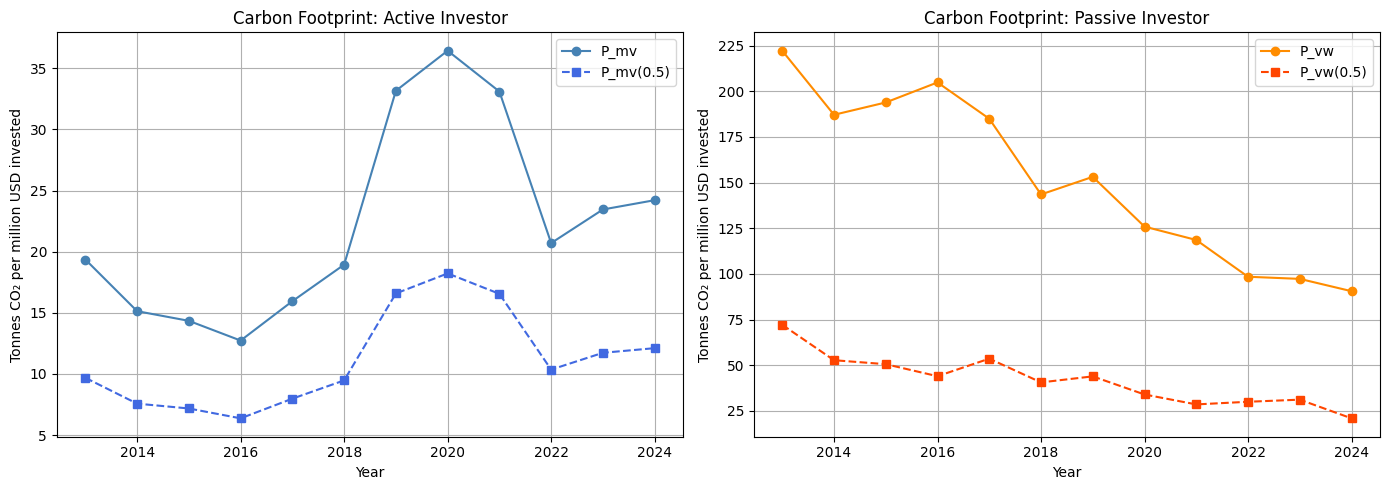

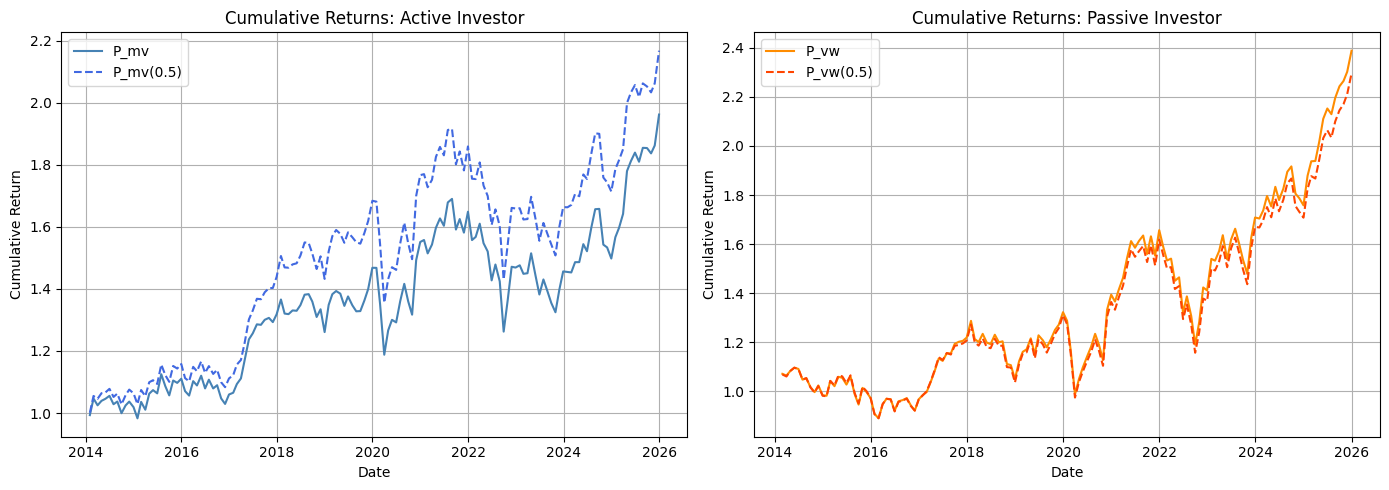

In [12]:
# Carbon footprint comparison
mv05_cf_series = pd.Series(mv05_cf).sort_index()
vw05_cf_series = pd.Series(vw05_cf).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Active investor comparison
axes[0].plot(cf_mv.index, cf_mv.values, marker='o', label="P_mv", color="steelblue")
axes[0].plot(mv05_cf_series.index, mv05_cf_series.values, marker='s',
             label="P_mv(0.5)", color="royalblue", linestyle='--')
axes[0].set_title("Carbon Footprint: Active Investor")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Tonnes CO₂ per million USD invested")
axes[0].legend()
axes[0].grid(True)

# Passive investor comparison
axes[1].plot(cf_vw.index, cf_vw.values, marker='o', label="P_vw", color="darkorange")
axes[1].plot(vw05_cf_series.index, vw05_cf_series.values, marker='s',
             label="P_vw(0.5)", color="orangered", linestyle='--')
axes[1].set_title("Carbon Footprint: Passive Investor")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Tonnes CO₂ per million USD invested")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "carbon_footprint_comparison.png", dpi=150)
plt.show()

# Cumulative returns comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cum_mv     = (1 + mv_returns_base.loc[common_mv]).cumprod()
cum_mv05   = (1 + mv05_returns.loc[common_mv]).cumprod()
cum_vw     = (1 + vw_returns_base.loc[common_vw]).cumprod()
cum_vw05   = (1 + vw05_returns.loc[common_vw]).cumprod()

axes[0].plot(cum_mv.index, cum_mv.values, label="P_mv", color="steelblue")
axes[0].plot(cum_mv05.index, cum_mv05.values, label="P_mv(0.5)", color="royalblue", linestyle='--')
axes[0].set_title("Cumulative Returns: Active Investor")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(cum_vw.index, cum_vw.values, label="P_vw", color="darkorange")
axes[1].plot(cum_vw05.index, cum_vw05.values, label="P_vw(0.5)", color="orangered", linestyle='--')
axes[1].set_title("Cumulative Returns: Passive Investor")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Return")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "cumulative_returns_comparison.png", dpi=150)
plt.show()

## 7. Section 4.1 — P_oos_vw(NZ): Net Zero Portfolio

We implement a 10% annual carbon reduction from the 2013 VW baseline:

CF(p)_Y ≤ (1 - 0.10)^(Y - 2013) × CF_vw(2013)

for Y = 2013, ..., 2024.

The optimization is the same tracking error minimization as Section 3.3,
but with a tightening carbon constraint each year.

In [13]:
theta    = 0.10
Y0       = 2013
cf_vw_Y0 = cf_vw[Y0]  # baseline VW CF in 2013

nz_returns_list = []
nz_dates_list   = []
nz_weights      = {}
nz_cf           = {}
nz_targets      = {}

for year in range(start_year, end_year + 1):

    end_date  = pd.Timestamp(f"{year}-12-31")
    past_cols = returns_matrix.columns[returns_matrix.columns <= end_date]
    past_cols = past_cols[-window:]

    if len(past_cols) < window:
        continue

    # Net zero target for year Y
    cf_target = (1 - theta) ** (year - Y0 + 1) * cf_vw_Y0
    nz_targets[year] = cf_target

    valid_isins = get_investment_set(
        year, returns_matrix, past_cols, has_carbon_global,
        e_over_cap_all, emissions_df, mv_year
    )

    if len(valid_isins) < 10:
        continue

    sub        = returns_matrix[past_cols].loc[valid_isins]
    sub_filled = sub.T.fillna(sub.T.mean()).T
    mu_sub     = sub_filled.values.mean(axis=1, keepdims=True)
    Sigma      = (sub_filled.values - mu_sub) @ (sub_filled.values - mu_sub).T / sub_filled.shape[1]
    Sigma      = Sigma + 1e-6 * np.eye(len(valid_isins))
    N          = len(valid_isins)

    # VW benchmark weights aligned to valid_isins
    vw_w = vw_weights_annual.get(year, pd.Series(dtype=float))
    vw_w = vw_w.reindex(valid_isins).fillna(0)
    vw_w = vw_w / vw_w.sum() if vw_w.sum() > 0 else pd.Series(np.ones(N)/N, index=valid_isins)
    w_vw = vw_w.values

    cf_vec = get_cf_vector(valid_isins, year, emissions_df, mv_year)

    def tracking_error(w):
        diff = w - w_vw
        return diff @ Sigma @ diff

    def tracking_error_grad(w):
        return 2 * Sigma @ (w - w_vw)

    constraints = [
        {'type': 'eq',  'fun': lambda w: np.sum(w) - 1,
                         'jac': lambda w: np.ones(N)},
        {'type': 'ineq','fun': lambda w: cf_target - cf_vec @ w,
                         'jac': lambda w: -cf_vec}
    ]
    bounds = [(0, 0.05)] * N
    w0     = w_vw.copy()

    result = minimize(
        tracking_error, w0,
        jac=tracking_error_grad,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 500}
    )

    if not result.success:
        print(f"Year {year}: P_vw(NZ) optimization failed — {result.message}")
        continue

    w = np.clip(result.x, 0, None)
    w = w / w.sum()

    nz_weights[year] = pd.Series(w, index=valid_isins)
    nz_cf[year]      = float(cf_vec @ w)

    rets, dates = simulate_returns(w, valid_isins, returns_matrix, end_date)
    nz_returns_list.extend(rets)
    nz_dates_list.extend(dates)

    print(f"Year {year}: CF = {nz_cf[year]:.2f} (target ≤ {cf_target:.2f})")

nz_returns = pd.Series(nz_returns_list, index=nz_dates_list).sort_index()
print(f"\nP_vw(NZ) returns shape: {nz_returns.shape}")

Year 2013: CF = 72.12 (target ≤ 200.02)
Year 2014: CF = 52.74 (target ≤ 180.02)
Year 2015: CF = 50.56 (target ≤ 162.02)
Year 2016: CF = 43.97 (target ≤ 145.81)
Year 2017: CF = 53.59 (target ≤ 131.23)
Year 2018: CF = 40.58 (target ≤ 118.11)
Year 2019: CF = 43.88 (target ≤ 106.30)
Year 2020: CF = 33.96 (target ≤ 95.67)
Year 2021: CF = 28.52 (target ≤ 86.10)
Year 2022: CF = 29.97 (target ≤ 77.49)
Year 2023: CF = 31.13 (target ≤ 69.74)
Year 2024: CF = 20.89 (target ≤ 62.77)

P_vw(NZ) returns shape: (144,)


## 8. Section 4.2 — Comparison: P_vw vs P_vw(0.5) vs P_vw(NZ)

In [14]:
# Align to common dates
common_all = vw_returns_base.index.intersection(vw05_returns.index).intersection(nz_returns.index)

stats_passive = pd.DataFrame({
    "P_vw":      compute_stats(vw_returns_base.loc[common_all]),
    "P_vw(0.5)": compute_stats(vw05_returns.loc[common_all]),
    "P_vw(NZ)":  compute_stats(nz_returns.loc[common_all])
}).T

print("=== Passive Investor Portfolio Comparison ===")
print(stats_passive.to_string())

=== Passive Investor Portfolio Comparison ===
           Annualized Return  Annualized Volatility  Sharpe Ratio  Min Monthly Return  Max Monthly Return
P_vw                  0.0858                 0.1587        0.4144             -0.1536              0.1822
P_vw(0.5)             0.0826                 0.1597        0.3919             -0.1542              0.1822
P_vw(NZ)              0.0826                 0.1597        0.3919             -0.1542              0.1822


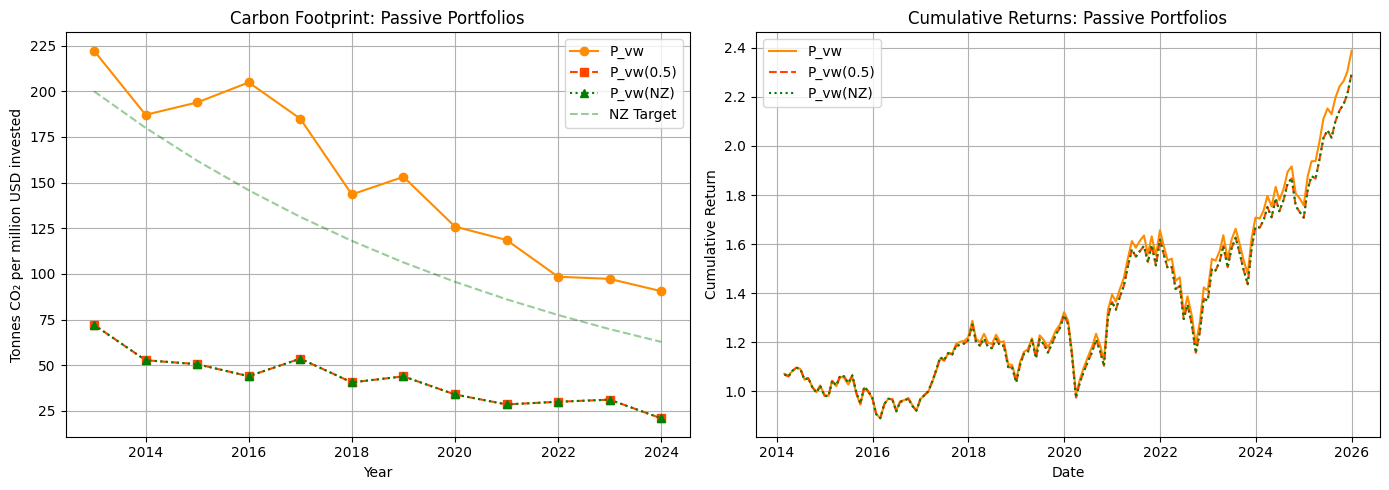

In [15]:
# Carbon footprint: P_vw vs P_vw(0.5) vs P_vw(NZ)
nz_cf_series      = pd.Series(nz_cf).sort_index()
nz_targets_series = pd.Series(nz_targets).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Carbon footprint
axes[0].plot(cf_vw.index, cf_vw.values, marker='o',
             label="P_vw", color="darkorange")
axes[0].plot(vw05_cf_series.index, vw05_cf_series.values, marker='s',
             label="P_vw(0.5)", color="orangered", linestyle='--')
axes[0].plot(nz_cf_series.index, nz_cf_series.values, marker='^',
             label="P_vw(NZ)", color="green", linestyle=':')
axes[0].plot(nz_targets_series.index, nz_targets_series.values,
             label="NZ Target", color="green", linestyle='--', alpha=0.4)
axes[0].set_title("Carbon Footprint: Passive Portfolios")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Tonnes CO₂ per million USD invested")
axes[0].legend()
axes[0].grid(True)

# Cumulative returns
cum_vw_all   = (1 + vw_returns_base.loc[common_all]).cumprod()
cum_vw05_all = (1 + vw05_returns.loc[common_all]).cumprod()
cum_nz       = (1 + nz_returns.loc[common_all]).cumprod()

axes[1].plot(cum_vw_all.index, cum_vw_all.values,
             label="P_vw", color="darkorange")
axes[1].plot(cum_vw05_all.index, cum_vw05_all.values,
             label="P_vw(0.5)", color="orangered", linestyle='--')
axes[1].plot(cum_nz.index, cum_nz.values,
             label="P_vw(NZ)", color="green", linestyle=':')
axes[1].set_title("Cumulative Returns: Passive Portfolios")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Return")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "passive_portfolios_comparison.png", dpi=150)
plt.show()

## 9. Summary Table — All Portfolios

In [16]:
# Full summary of all 5 portfolios
common_final = (mv_returns_base.index
                .intersection(mv05_returns.index)
                .intersection(vw_returns_base.index)
                .intersection(vw05_returns.index)
                .intersection(nz_returns.index))

stats_all = pd.DataFrame({
    "P_mv":      compute_stats(mv_returns_base.loc[common_final]),
    "P_mv(0.5)": compute_stats(mv05_returns.loc[common_final]),
    "P_vw":      compute_stats(vw_returns_base.loc[common_final]),
    "P_vw(0.5)": compute_stats(vw05_returns.loc[common_final]),
    "P_vw(NZ)":  compute_stats(nz_returns.loc[common_final])
}).T

print("=== Full Portfolio Summary ===")
print(stats_all.to_string())

=== Full Portfolio Summary ===
           Annualized Return  Annualized Volatility  Sharpe Ratio  Min Monthly Return  Max Monthly Return
P_mv                  0.0656                 0.1294        0.3523             -0.1209              0.1335
P_mv(0.5)             0.0729                 0.1261        0.4196             -0.1223              0.1363
P_vw                  0.0858                 0.1587        0.4144             -0.1536              0.1822
P_vw(0.5)             0.0826                 0.1597        0.3919             -0.1542              0.1822
P_vw(NZ)              0.0826                 0.1597        0.3919             -0.1542              0.1822


## 10. Key Takeaways

- **P_mv(0.5)** imposes a 50% CF reduction on the already low-carbon MV portfolio.
  The constraint is binding and may push the optimizer toward different sectors.

- **P_vw(0.5)** stays close to the market benchmark while halving its carbon footprint.
  The tracking error cost tells us how much we "pay" in terms of deviation from the market.

- **P_vw(NZ)** implements a cumulative 10% annual reduction path starting from the 2013
  VW baseline. In later years the constraint becomes very tight and may be infeasible
  for some firms, reflecting the real difficulty of achieving net zero.

- The financial cost of decarbonization (reduction in Sharpe ratio or return) should be
  compared across portfolios to evaluate the trade-off between financial performance
  and climate impact.